In [1]:
import numpy as np
import scipy.fft
import scipy.ndimage
import scipy.signal
import scipy.io.wavfile
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
import os

In [2]:
testcases = [
    os.path.join('../testcases', x)
    for x in [
        '00-10x10-squares.png',
        '01-10x10-squares.png',
        '02-10x10-squares.png',
        '03-6x6-squares.png',
        '04-6x6-squares.png',
        '05-6x6-squares.png',
        '06-15x15-squares.png',
        '07-15x15-squares.png',
        '08-15x15-squares.png',
        '09-25x25-squares.png',
        '10-25x25-squares.png'
    ]
]

def load_case(case):
    im = Image.open(case)
    im = np.array(im.convert('L'), dtype='f') / 255.0
    return im

testcase = testcases[1]
print(testcase)
im = load_case(testcase)
im = 1.0 - im
im.dtype, im.shape

../testcases/01-10x10-squares.png


(dtype('float32'), (454, 454))

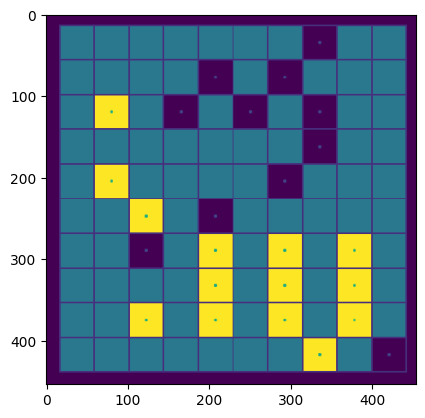

In [3]:
plt.figure()
plt.imshow(im)
plt.show()

(454,) (454,)


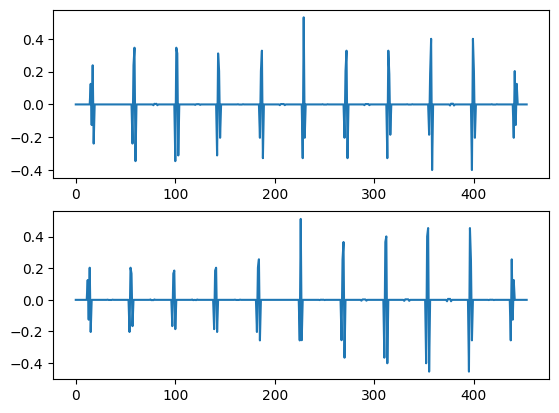

In [63]:
def reduce_im(im):
    reduce_y = np.mean(im, axis=0).flatten()
    reduce_x = np.mean(im, axis=1).flatten()
    reduce_y = np.convolve(np.pad(reduce_y, 1, 'edge'), [1,-2,1], 'valid')
    reduce_x = np.convolve(np.pad(reduce_x, 1, 'edge'), [1,-2,1], 'valid')
    return reduce_y, reduce_x

reduce_y, reduce_x = reduce_im(im)
print(reduce_y.shape, reduce_x.shape)
fig, (ax1, ax2) = plt.subplots(2)
ax1.plot(reduce_y)
ax2.plot(reduce_x)
plt.show()

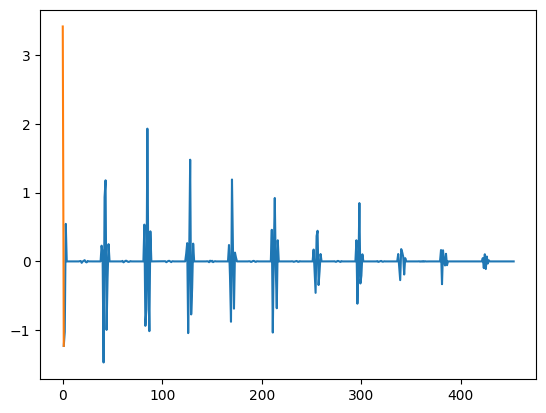

In [64]:
sig = reduce_y
corr = scipy.signal.correlate(sig, sig, 'full')
corr = corr[len(corr)//2:]
plt.figure()
plt.plot(np.arange(1, len(corr)), corr[1:])
plt.plot([0, 1], corr[0:2])
plt.show()

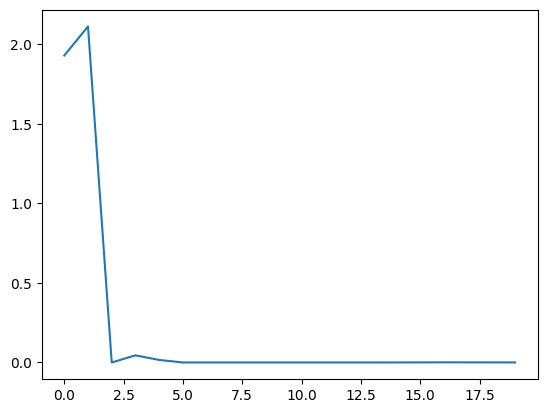

In [95]:
peak = float(np.argmax(corr[1:]) + 1)
subharms = np.array([1.0 / x for x in range(1,int(peak/4))])
values = np.interp(peak * subharms, np.arange(len(corr)), corr) / subharms
plt.plot(np.arange(len(values)), values)
plt.show()